In [ ]:
import sys
from pathlib import Path

# add project root to Python path
project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
    
from scripts.preprocess_clustering import preproc_and_features_joint
# ============== Config ==============
TRAIN_AD_PATH = "../../Dataset/train_data/train_adata.h5ad"
TEST_AD_PATH  = "../../Dataset/test_data/test_adata.h5ad"
import scanpy as sc

ad_tr = sc.read_h5ad(TRAIN_AD_PATH)
ad_te = sc.read_h5ad(TEST_AD_PATH)
# Harmony 同時校正 Sample + Patient（合併成一個 batch 欄）
ad_tr_feat, ad_te_feat = preproc_and_features_joint(
    ad_tr_raw=ad_tr,
    ad_te_raw=ad_te,
    do_winsor=False,do_asinh=False,
    n_top_hvg=3000, 
    marker_topk_ct=120,
    label_col="highLevelType",
    sample_col="Sample",
    harmony_batch_keys="Sample",  # ✅ 多個 batch 一起校正（串接成單一 key）
    out_obsm_key="X_clust_like_deconv",
)


/opt/anaconda3/envs/ml4g-project2/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/ml4g-project2/l

/var/folders/7g/j5s0yzcj34l3v043s7znkplc0000gn/T/ipykernel_58516/3589919997.py:10: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(tr_ct):
/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


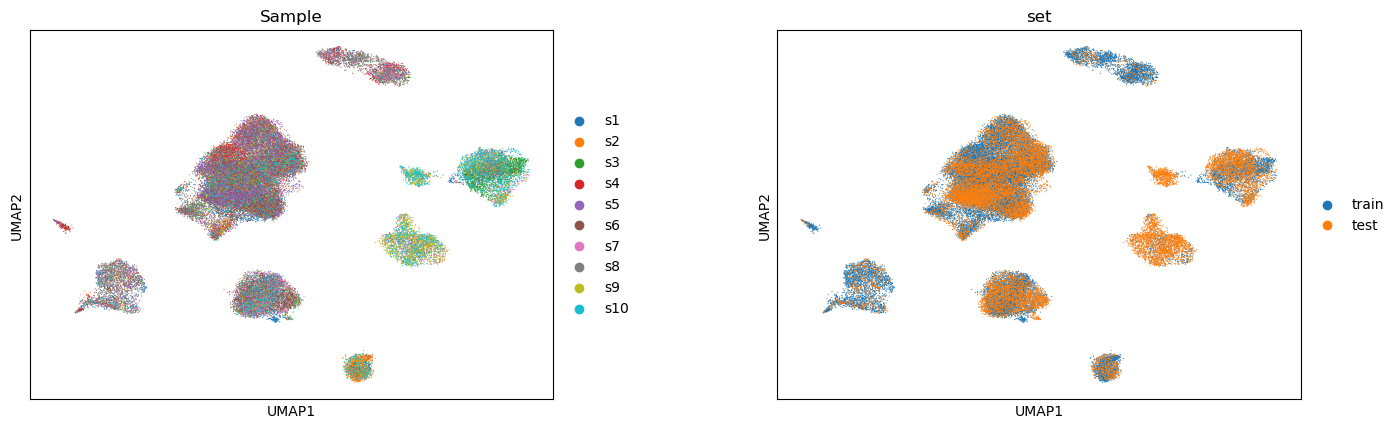

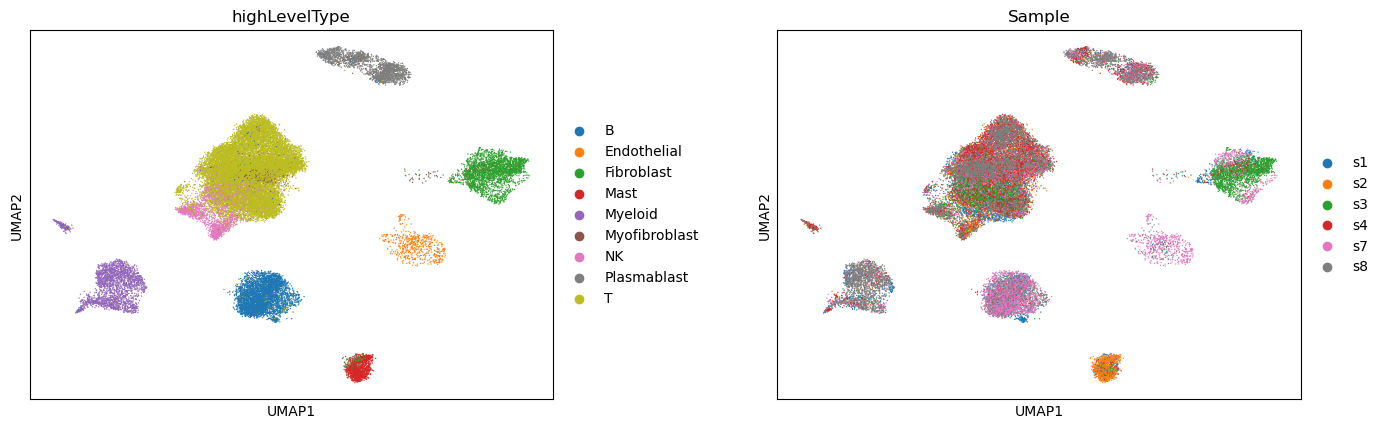

In [7]:
import numpy as np
import pandas as pd
import scanpy as sc

SAMPLE_COL = "Sample"
# 1) 對齊 obs 欄位：補上 test 的 highLevelType（用與 train 相同的類別 + "UNK"）
if "highLevelType" in ad_tr_feat.obs.columns:
    tr_ct = ad_tr_feat.obs["highLevelType"]
    # 取 train 的類別（若不是 categorical，先轉）
    if not pd.api.types.is_categorical_dtype(tr_ct):
        tr_ct = tr_ct.astype("category")
        ad_tr_feat.obs["highLevelType"] = tr_ct
    cats = list(tr_ct.cat.categories) + (["UNK"] if "UNK" not in tr_ct.cat.categories else [])
else:
    # 極端情況：train 也沒有 highLevelType，就用單一 "UNK"
    cats = ["UNK"]

if "highLevelType" not in ad_te_feat.obs.columns:
    ad_te_feat.obs["highLevelType"] = pd.Categorical(["UNK"] * ad_te_feat.n_obs, categories=cats)
else:
    # 若 test 有，但不是同一組類別，統一到相同 categories（加上兩邊缺的）
    te_ct = ad_te_feat.obs["highLevelType"].astype("category")
    union_cats = sorted(set(cats).union(te_ct.cat.categories))
    ad_tr_feat.obs["highLevelType"] = ad_tr_feat.obs["highLevelType"].astype("category").cat.set_categories(union_cats)
    ad_te_feat.obs["highLevelType"] = te_ct.cat.set_categories(union_cats)

# 2) 合併（修正 join 參數）
combined = sc.concat(
    [ad_tr_feat, ad_te_feat],
    label="set",
    keys=["train", "test"],
    join="inner"  # 或 "outer"，但建議 inner 比較穩
)

# 3) 在 combined 上建圖/UMAP（用你準備好的嵌入）
# 確保兩個物件都有 obsm["X_clust_like_deconv"]，且維度一致
if "X_clust_like_deconv" not in combined.obsm:
    raise KeyError("combined.obsm 內找不到 'X_clust_like_deconv'，請確認 ad_tr_feat/ad_te_feat 皆已計算好該嵌入。")

sc.pp.neighbors(combined, use_rep="X_clust_like_deconv", n_neighbors=15, metric="euclidean")
sc.tl.umap(combined, random_state=42)

# 4) 直接在 combined 畫圖（Sample / set / highLevelType）
sc.pl.umap(combined, color=[SAMPLE_COL, "set"], ncols=3, wspace=0.3)

# 5) 需要時再切回
ad_tr_umap = combined[combined.obs["set"] == "train"].copy()
ad_te_umap = combined[combined.obs["set"] == "test"].copy()

# 個別作圖
sc.pl.umap(ad_tr_umap, color=["highLevelType", SAMPLE_COL], ncols=2, wspace=0.3)

In [8]:
import os
OUT_DIR = "./outputs_features_csv/"

LABEL_COL  = "highLevelType"

# ---------- Pack to DataFrame (with meta) ----------
if "pct_counts_mt" not in combined.obs.columns:
    combined.obs["pct_counts_mt"] = np.nan
meta = pd.DataFrame({
    "cell_type": combined.obs[LABEL_COL].astype(str).values,
    "Sample":    combined.obs[SAMPLE_COL].astype(str).values,
    "pct_counts_mt": pd.to_numeric(combined.obs["pct_counts_mt"], errors="coerce")
}, index=combined.obs_names)


df_comb = pd.DataFrame(combined.obsm['X_clust_like_deconv'],       index=combined.obs_names)


df_comb = pd.concat([meta, df_comb], axis=1)


comb_path = os.path.join(OUT_DIR, "features.csv")
os.makedirs(OUT_DIR, exist_ok=True)
df_comb.to_csv(comb_path)
print(f"[OK] wrote:\n - {comb_path}  shape={df_comb.shape}")

[OK] wrote:
 - ./outputs_features_csv/features.csv  shape=(50990, 103)
